In [1]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp

# Dodanie ścieżki do zad2 dla solverów
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Parametry "Prawdziwe" (Ground Truth)
TRUE_PARAMS = {
    'D': 0.1,
    'p': 0.01,
    'q': 1.0
}
T_END = 5.0
NX = 100
DT = 1e-3

Using device: cuda


## 1. Generowanie Danych Ground Truth (PDE)

In [2]:
def generate_pde_data():
    try:
        from solvers import _neumann_laplacian, reaction, initial_condition
        import scipy.sparse as sp
        import scipy.sparse.linalg as spla
        
        nx = NX
        dt = DT
        tend = T_END
        D = TRUE_PARAMS['D']
        p = TRUE_PARAMS['p']
        q = TRUE_PARAMS['q']
        
        dx = 1.0 / (nx - 1)
        x = np.linspace(0, 1, nx)
        u = initial_condition(nx, dx, kind='gaussian')
        
        A = _neumann_laplacian(nx, dx)
        M_l = sp.eye(nx) - 0.5 * dt * D * A
        M_r = sp.eye(nx) + 0.5 * dt * D * A
        
        nsteps = int(np.ceil(tend / dt))
        u_all = [u.copy()]
        t_all = [0.0]
        current_t = 0.0
        
        for n in range(nsteps):
            Ru = reaction(u, p, q)
            rhs = M_r.dot(u) + dt * Ru
            u = spla.spsolve(M_l, rhs)
            current_t += dt
            if (n + 1) % 10 == 0:
                u_all.append(u.copy())
                t_all.append(current_t)
                
        return x, np.array(t_all), np.array(u_all).T
    except ImportError:
        print("Brak modułu solvers.py. Upewnij się, że jesteś w odpowiednim katalogu.")
        return None, None, None

x_true, t_true, u_true = generate_pde_data()
u_true_mean = np.mean(u_true, axis=0) # Średnia przestrzenna dla porównania z ODE

print(f"Dane PDE wygenerowane: {u_true.shape}")

Dane PDE wygenerowane: (100, 501)


## 2. Supermodel ODE

Stworzymy zespół 3 modeli ODE z zaburzonymi parametrami. Modele będą sprzężone (coupled) poprzez człon relaksacyjny dążący do średniej zespołu (Nudging).

Równanie $i$-tego modelu:
$$ \frac{dU_i}{dt} = f(U_i, p_i, q_i) + C \cdot (\bar{U} - U_i) $$
gdzie $\bar{U} = \frac{1}{N} \sum U_j$.

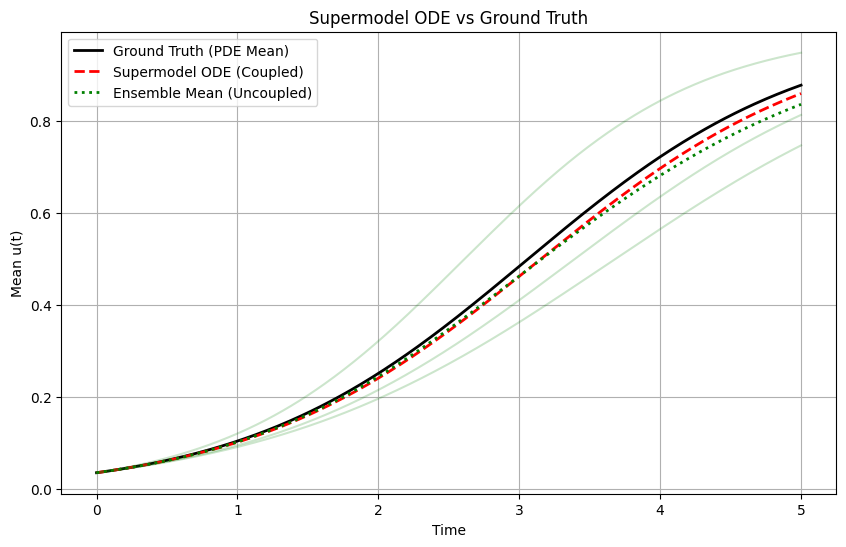

In [3]:
# Definicja zaburzonych parametrów
models_params = [
    {'p': TRUE_PARAMS['p'] * 0.8, 'q': TRUE_PARAMS['q'] * 1.2}, # Model 1: niedoszacowane p, przeszacowane q
    {'p': TRUE_PARAMS['p'] * 1.2, 'q': TRUE_PARAMS['q'] * 0.8}, # Model 2: przeszacowane p, niedoszacowane q
    {'p': TRUE_PARAMS['p'] * 0.9, 'q': TRUE_PARAMS['q'] * 0.9}, # Model 3: oba niedoszacowane
]

C_coupling = 5.0 # Siła sprzężenia

def supermodel_ode_system(t, y):
    # y to wektor [U1, U2, U3]
    U = y
    U_mean = np.mean(U)
    
    dydt = []
    for i, params in enumerate(models_params):
        p = params['p']
        q = params['q']
        u_val = U[i]
        
        # Dynamika własna
        f_val = (p + q * u_val) * (1 - u_val)
        
        # Sprzężenie
        coupling = C_coupling * (U_mean - u_val)
        
        dydt.append(f_val + coupling)
        
    return dydt

# Warunek początkowy (średnia z PDE)
u0_val = u_true_mean[0]
y0 = [u0_val, u0_val, u0_val]

# Rozwiązanie Supermodelu
sol_super = solve_ivp(supermodel_ode_system, [t_true[0], t_true[-1]], y0, t_eval=t_true)
u_super_all = sol_super.y # (3, NT)
u_super_mean = np.mean(u_super_all, axis=0)

# Rozwiązanie modeli niezależnych (bez sprzężenia) dla porównania
u_indep_all = []
for params in models_params:
    def ode_single(t, u):
        return (params['p'] + params['q'] * u) * (1 - u)
    sol = solve_ivp(ode_single, [t_true[0], t_true[-1]], [u0_val], t_eval=t_true)
    u_indep_all.append(sol.y.flatten())
u_indep_all = np.array(u_indep_all)
u_indep_mean = np.mean(u_indep_all, axis=0)

# Wizualizacja ODE
plt.figure(figsize=(10, 6))
plt.plot(t_true, u_true_mean, 'k-', linewidth=2, label='Ground Truth (PDE Mean)')
plt.plot(t_true, u_super_mean, 'r--', linewidth=2, label='Supermodel ODE (Coupled)')
plt.plot(t_true, u_indep_mean, 'g:', linewidth=2, label='Ensemble Mean (Uncoupled)')

for i in range(3):
    plt.plot(t_true, u_indep_all[i], 'g-', alpha=0.2)

plt.legend()
plt.title('Supermodel ODE vs Ground Truth')
plt.xlabel('Time')
plt.ylabel('Mean u(t)')
plt.grid(True)
plt.savefig('supermodel_ode_results.png')
plt.show()

## 3. SuperNet PINN

Stworzymy zespół 3 sieci PINN. Każda sieć będzie uczona z użyciem "fizyki" opartej na zaburzonych parametrach (takich jak w Supermodelu ODE). Dodatkowo wprowadzimy **Coupling Loss**, który karze odchylenia wyjścia każdej sieci od średniej wyjścia całego zespołu.

$$ L_{total} = \sum_{i=1}^3 (L_{data, i} + L_{physics, i}) + \lambda_{couple} \sum_{i=1}^3 ||u_i - \bar{u}||^2 $$

In [4]:
# Przygotowanie danych treningowych (wspólne dla wszystkich sieci)
X, T = np.meshgrid(x_true, t_true)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
u_flat = u_true.T.flatten()[:, None]

# Losowe punkty pomiarowe (mała ilość - np. 500)
N_data = 500
idx = np.random.choice(X_flat.shape[0], N_data, replace=False)
X_train = np.hstack((X_flat[idx], T_flat[idx]))
u_train = u_flat[idx]

# Punkty kolokacji
N_col = 5000
X_col = np.random.uniform(0, 1, (N_col, 1))
T_col = np.random.uniform(0, T_END, (N_col, 1))
XT_col = np.hstack((X_col, T_col))

# Tensory
X_u_train = torch.tensor(X_train, dtype=torch.float32).to(device)
u_train_tensor = torch.tensor(u_train, dtype=torch.float32).to(device)
X_f_train = torch.tensor(XT_col, dtype=torch.float32).to(device)

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1)
        )
    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

def physics_loss_pinn(model, x, t, params):
    x.requires_grad = True
    t.requires_grad = True
    u = model(x, t)
    
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    D = TRUE_PARAMS['D'] # Zakładamy, że D jest znane lub stałe, zaburzamy p i q
    p = params['p']
    q = params['q']
    
    f = u_t - D * u_xx - (p + q * u) * (1 - u)
    return torch.mean(f ** 2)

# Inicjalizacja zespołu sieci
models = [PINN().to(device) for _ in range(3)]
optimizers = [torch.optim.Adam(m.parameters(), lr=1e-3) for m in models]

epochs = 3000
lambda_couple = 1.0

loss_history = []

print("Rozpoczynam trening SuperNet...")
start_time = time.time()

for epoch in range(epochs):
    # Zerowanie gradientów
    for opt in optimizers:
        opt.zero_grad()
        
    # Forward pass dla wszystkich modeli
    x_data = X_u_train[:, 0:1]
    t_data = X_u_train[:, 1:2]
    
    u_preds_data = [m(x_data, t_data) for m in models]
    
    # Data Loss (każdy model uczy się danych)
    losses_data = [torch.mean((up - u_train_tensor) ** 2) for up in u_preds_data]
    
    # Physics Loss (każdy model ma swoje zaburzone parametry)
    x_col = X_f_train[:, 0:1]
    t_col = X_f_train[:, 1:2]
    
    losses_phy = []
    u_preds_col = [] # Do couplingu w punktach kolokacji
    
    for i, m in enumerate(models):
        l_phy = physics_loss_pinn(m, x_col, t_col, models_params[i])
        losses_phy.append(l_phy)
        u_preds_col.append(m(x_col, t_col))
        
    # Coupling Loss (w punktach kolokacji)
    # Obliczamy średnią predykcję zespołu
    u_stack = torch.stack(u_preds_col, dim=0)
    u_mean = torch.mean(u_stack, dim=0)
    
    # Loss to odległość każdego modelu od średniej
    loss_couple = torch.mean((u_stack - u_mean) ** 2)
    
    # Sumowanie i backward
    total_loss = 0
    for i in range(3):
        loss_i = losses_data[i] + losses_phy[i] + lambda_couple * loss_couple
        loss_i.backward(retain_graph=True) # retain_graph potrzebne bo współdzielimy loss_couple
        total_loss += loss_i.item()
        
    for opt in optimizers:
        opt.step()
        
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}, Total Loss: {total_loss:.6f}, Couple Loss: {loss_couple.item():.6f}")

print(f"Trening zakończony w {time.time() - start_time:.2f}s")

Rozpoczynam trening SuperNet...


c:\Users\looxx\Desktop\studia\informatyka_systemow_zlozonych\ISZ-Project\.venv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 500, Total Loss: 0.002092, Couple Loss: 0.000060
Epoch 1000, Total Loss: 0.001516, Couple Loss: 0.000067
Epoch 1000, Total Loss: 0.001516, Couple Loss: 0.000067
Epoch 1500, Total Loss: 0.001087, Couple Loss: 0.000071
Epoch 1500, Total Loss: 0.001087, Couple Loss: 0.000071
Epoch 2000, Total Loss: 0.000914, Couple Loss: 0.000074
Epoch 2000, Total Loss: 0.000914, Couple Loss: 0.000074
Epoch 2500, Total Loss: 0.001021, Couple Loss: 0.000102
Epoch 2500, Total Loss: 0.001021, Couple Loss: 0.000102
Epoch 3000, Total Loss: 0.000798, Couple Loss: 0.000072
Trening zakończony w 130.92s
Epoch 3000, Total Loss: 0.000798, Couple Loss: 0.000072
Trening zakończony w 130.92s


## 4. Ewaluacja i Porównanie

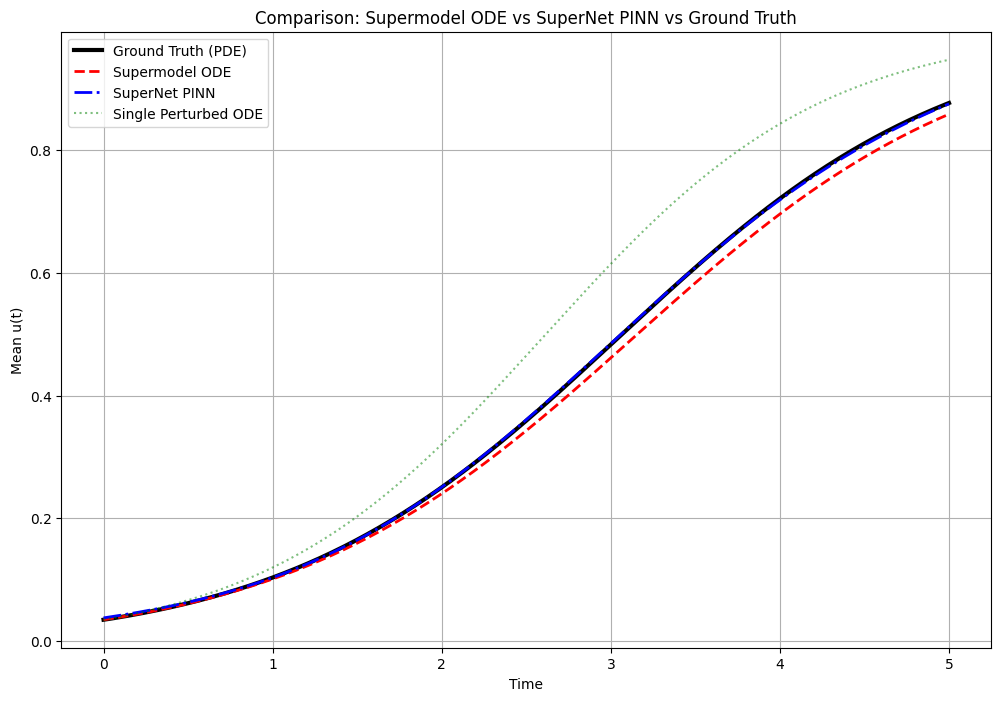

RMSE Supermodel ODE: 0.016811
RMSE SuperNet PINN: 0.001654
RMSE Single Perturbed ODE: 0.089763


In [5]:
# Ewaluacja SuperNet na siatce
X_grid, T_grid = np.meshgrid(x_true, t_true)
X_flat_eval = X_grid.flatten()[:, None]
T_flat_eval = T_grid.flatten()[:, None]

x_eval = torch.tensor(X_flat_eval, dtype=torch.float32).to(device)
t_eval = torch.tensor(T_flat_eval, dtype=torch.float32).to(device)

u_preds_eval = []
with torch.no_grad():
    for m in models:
        u_preds_eval.append(m(x_eval, t_eval).cpu().numpy())

u_supernet_mean_flat = np.mean(np.array(u_preds_eval), axis=0)
u_supernet_grid = u_supernet_mean_flat.reshape(X_grid.shape)

# Obliczanie średniej przestrzennej dla SuperNet
u_supernet_spatial_mean = np.mean(u_supernet_grid, axis=1)

# Wykres porównawczy wszystkich podejść
plt.figure(figsize=(12, 8))

# 1. Ground Truth
plt.plot(t_true, u_true_mean, 'k-', linewidth=3, label='Ground Truth (PDE)')

# 2. Supermodel ODE
plt.plot(t_true, u_super_mean, 'r--', linewidth=2, label='Supermodel ODE')

# 3. SuperNet PINN
plt.plot(t_true, u_supernet_spatial_mean, 'b-.', linewidth=2, label='SuperNet PINN')

# 4. Pojedynczy zaburzony model ODE (dla kontekstu)
plt.plot(t_true, u_indep_all[0], 'g:', alpha=0.5, label='Single Perturbed ODE')

plt.title('Comparison: Supermodel ODE vs SuperNet PINN vs Ground Truth')
plt.xlabel('Time')
plt.ylabel('Mean u(t)')
plt.legend()
plt.grid(True)
plt.savefig('supermodel_vs_supernet.png')
plt.show()

# Obliczenie błędów RMSE dla średnich trajektorii
rmse_ode = np.sqrt(np.mean((u_true_mean - u_super_mean)**2))
rmse_pinn = np.sqrt(np.mean((u_true_mean - u_supernet_spatial_mean)**2))
rmse_single = np.sqrt(np.mean((u_true_mean - u_indep_all[0])**2))

print(f"RMSE Supermodel ODE: {rmse_ode:.6f}")
print(f"RMSE SuperNet PINN: {rmse_pinn:.6f}")
print(f"RMSE Single Perturbed ODE: {rmse_single:.6f}")